## CVRP

In [4]:
%pip install pulp pandas -q

import pulp
import pandas as pd
import math

# DADOS
coords = {
    0: (0, 0),   # deposito
    1: (2, 2),
    2: (4, 2),
    3: (6, 1),
    4: (5, 4)
}
n = len(coords) # nos (0..4)
clientes = list(range(1, n))
demanda = {0: 0, 1: 3, 2: 2, 3: 4, 4: 1}
Q = 6 # capacidade do veiculo

# Matriz de distancias (arredondada)
dist = [[0]*n for _ in range(n)]
for i in range(n):
    for j in range(n):
        if i != j:
            dx = coords[i][0] - coords[j][0]
            dy = coords[i][1] - coords[j][1]
            dist[i][j] = int(round(math.sqrt(dx*dx + dy*dy)))

# TABELA 1: MATRIZ DE CUSTOS
df_custos = pd.DataFrame(dist,
                         index=[f"no {i}" for i in range(n)],
                         columns=[f"no {j}" for j in range(n)])
print("\n MATRIZ DE DISTÂNCIAS ENTRE TODOS OS NÓS \n")
display(df_custos)

# MODELO PLI (CVRP)
prob = pulp.LpProblem("CVRP", pulp.LpMinimize)

# Variaveis x_ij binarias
x = [[pulp.LpVariable(f"x_{i}_{j}", cat='Binary') for j in range(n)] for i in range(n)]

# Variaveis u_i (carga ao sair do nó i)
u = [pulp.LpVariable(f"u_{i}", lowBound=0, upBound=Q, cat='Continuous') for i in range(n)]
u[0] = 0   # depósito carga zero

# Restricao 1: cada cliente tem exatamente um predecessor e um sucessor (fluxo)
for i in clientes:
    prob += pulp.lpSum(x[i][j] for j in range(n) if j != i) == 1   # sai do cliente
    prob += pulp.lpSum(x[j][i] for j in range(n) if j != i) == 1   # entra no cliente

# Deposito: fluxo de saída = fluxo de entrada (não fixamos número de veículos)
prob += pulp.lpSum(x[0][j] for j in clientes) == pulp.lpSum(x[j][0] for j in clientes)

# Restricoes de capacidade e eliminação de sub-rotas (MTZ para CVRP)
for i in clientes:
    for j in clientes:
        if i != j:
            prob += u[j] >= u[i] + demanda[j] - Q * (1 - x[i][j])

# Funcao obj: minimizar custo total (distancia)
prob += pulp.lpSum(dist[i][j] * x[i][j] for i in range(n) for j in range(n) if i != j)

prob.solve(pulp.PULP_CBC_CMD(msg=False))

# EXTRAIR ROTAS
arestas_usadas = [(i, j) for i in range(n) for j in range(n) if i != j and x[i][j].varValue > 0.5]

# Construir rotas saindo do deposito (0)
rotas = []
visitados = set()
for start in clientes:
    if start in visitados:
        continue
    # tenta comecar uma rota a partir do deposito
    for i in range(n):
        if (0, i) in arestas_usadas and i == start:
            rota = [0, i]
            atual = i
            while atual != 0:
                for j in range(n):
                    if (atual, j) in arestas_usadas and j != 0:
                        rota.append(j)
                        atual = j
                        break
                else:  # se não encontrou, é porque chegou ao deposito, Mas tem que ter retorno.
                    for j in range(n):
                        if (atual, j) in arestas_usadas and j == 0:
                            rota.append(0)
                            atual = 0
                            break
                    break
            # remove duplicacao do deposito no final
            if rota[-1] == 0:
                pass
            rotas.append(rota)
            visitados.update(rota)
            break

# se houver mais de uma rota, cada uma começa e termina no deposito.
# exibicao das rotas como listas de nos (incluindo deposito no início e fim)
print("\n ROTAS ENCONTRADAS\n")
for r in rotas:
    # nomes dos nos
    nomes = [str(no) for no in r]
    print(" -> ".join(nomes))
    # calcular carga total
    carga = sum(demanda[no] for no in r if no != 0)
    print(f"  Carga total: {carga} / {Q}\n")

# TABELA DE ARCOS PERCORRIDOS
dados_arcos = []
for (i, j) in arestas_usadas:
    dados_arcos.append({
        'Origem': i,
        'Destino': j,
        'Distância': dist[i][j]
    })
df_arcos = pd.DataFrame(dados_arcos)
print("\n ARCOS USADOS NA SOLUÇÃO \n")
display(df_arcos)

print(f"\nCusto total da solução: {pulp.value(prob.objective):.0f}")

Note: you may need to restart the kernel to use updated packages.

 MATRIZ DE DISTÂNCIAS ENTRE TODOS OS NÓS 



,no 0,no 1,no 2,no 3,no 4
no 0,0,3,4,6,6
no 1,3,0,2,4,4
no 2,4,2,0,2,2
no 3,6,4,2,0,3
no 4,6,4,2,3,0



 ROTAS ENCONTRADAS

0 -> 2 -> 1 -> 0
  Carga total: 5 / 6

0 -> 4 -> 3 -> 0
  Carga total: 5 / 6


 ARCOS USADOS NA SOLUÇÃO 



,Origem,Destino,Distância
0,0,2,4
1,0,4,6
2,1,0,3
3,2,1,2
4,3,0,6
5,4,3,3



Custo total da solução: 24


Note: you may need to restart the kernel to use updated packages.


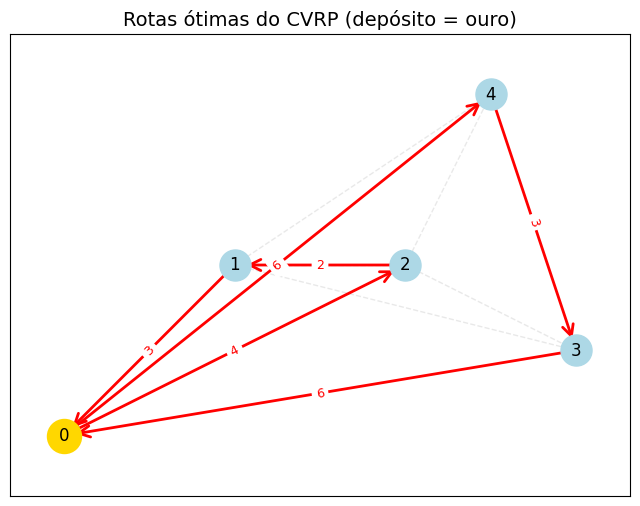

In [5]:
%pip install networkx matplotlib -q

import networkx as nx
import matplotlib.pyplot as plt

# grafo direcionado com as rotas
G = nx.DiGraph()
for (i, j) in arestas_usadas:
    G.add_edge(i, j, weight=dist[i][j])

pos = coords
plt.figure(figsize=(8,6))

# Desenhar todas as arestas possíveis (cinza claro)
G_all = nx.complete_graph(n)
nx.draw_networkx_edges(G_all, pos, edge_color='lightgray', width=1, alpha=0.5, style='dashed')

# Desenhar rotas (vermelho)
nx.draw_networkx_edges(G, pos, edge_color='red', width=2, arrows=True, arrowsize=20, arrowstyle='->')
nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=500)
nx.draw_networkx_labels(G, pos, labels={i: f"{i}" for i in range(n)}, font_size=12)
nx.draw_networkx_nodes(G, pos, nodelist=[0], node_color='gold', node_size=600)  # depósito destacado

# Rotulos das distancias
edge_labels = {(i, j): str(dist[i][j]) for (i, j) in arestas_usadas}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red', font_size=9)

plt.title("Rotas ótimas do CVRP (depósito = ouro)", fontsize=14)
plt.axis('equal')
plt.show()